In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
import numpy as np
from multistyleseg.analysis.dr_grading.utils import categorize_lesions_by_region
from multistyleseg.analysis.dr_grading.plot import plot_image_lesions
from multistyleseg.analysis.dr_grading.consts import DDR_TRAIN, DDR_TEST
from multistyleseg.analysis.io import fast_load_dir

In [2]:
# Execute for both directories
lesions_df_test = fast_load_dir("test/ensemble_inference/lesions")
ods_df_test = fast_load_dir("test/od_mac/pickles")


  0%|          | 0/3759 [00:00<?, ?it/s]

  0%|          | 0/3759 [00:00<?, ?it/s]

In [11]:
lesions_df_test.head(5)

,image_id,lesion_id,image_path,area,centroid,bbox,coordinates,contours
0,007-2920-100,MICROANEURYSMS,ensemble_inference/segmentations/007-2920-100.png,62.0,"(504.06451612903226, 845.3709677419355)","(500, 841, 509, 850)","[[500, 844], [500, 845], [500, 846], [500, 847...","[[[508.5, 847.0], [508.5, 846.0], [508.5, 845...."
1,007-2920-100,EXUDATES,ensemble_inference/segmentations/007-2920-100.png,62.0,"(557.0483870967741, 854.9032258064516)","(553, 851, 562, 860)","[[553, 853], [553, 854], [553, 855], [554, 852...","[[[561.5, 856.0], [561.5, 855.0], [561.5, 854...."
2,007-2920-100,EXUDATES,ensemble_inference/segmentations/007-2920-100.png,114.0,"(642.1491228070175, 836.0087719298245)","(636, 831, 649, 842)","[[636, 834], [636, 835], [636, 836], [636, 837...","[[[648.5, 838.0], [648.5, 837.0], [648.5, 836...."
3,007-2920-100,MICROANEURYSMS,ensemble_inference/segmentations/007-2920-100.png,6.0,"(661.8333333333334, 661.8333333333334)","(661, 661, 664, 664)","[[661, 661], [661, 662], [662, 661], [662, 662...","[[[663.5, 662.0], [663.0, 661.5], [662.5, 661...."
4,007-2920-100,MICROANEURYSMS,ensemble_inference/segmentations/007-2920-100.png,57.0,"(709.4561403508771, 601.140350877193)","(706, 597, 714, 606)","[[706, 599], [706, 600], [706, 601], [706, 602...","[[[713.5, 604.0], [713.5, 603.0], [713.5, 602...."


In [21]:
geo_df = categorize_lesions_by_region(lesions_df_test, ods_df_test)

In [23]:
geo_df

metric                       count                                      \
region                   OD region                                       
lesion            COTTON_WOOL_SPOT EXUDATES HEMORRHAGES MICROANEURYSMS   
image_id                                                                 
007-2809-100                     0        0           0              0   
007-2811-100                     0        0           0              0   
007-2812-100                     0        0           0              0   
007-2814-100                     0        0           0              0   
007-2815-100                     0        0           0              0   
...                            ...      ...         ...            ...   
20170630161546569                0        0           0              0   
20170630161546674                0        0           0              0   
20170630162228394                0        0           0              0   
20170630165124941                0        0           0              0   
20170630165348383                0        0           0              0   

metric                                                                  \
region               macula region                                       
lesion            COTTON_WOOL_SPOT EXUDATES HEMORRHAGES MICROANEURYSMS   
image_id                                                                 
007-2809-100                     0        1           0              1   
007-2811-100                     0        0           0              1   
007-2812-100                     0        0           0              0   
007-2814-100                     0        0           0              1   
007-2815-100                     0       13           0              0   
...                            ...      ...         ...            ...   
20170630161546569                0        0           0              0   
20170630161546674                0        2           0              1   
20170630162228394                0        1           0              1   
20170630165124941                0        0           0              0   
20170630165348383                0        0           0              0   

metric                                          ...     mean_area  \
region            1OD-2OD from macula           ... macula region   
lesion               COTTON_WOOL_SPOT EXUDATES  ...   HEMORRHAGES   
image_id                                        ...                 
007-2809-100                        0        4  ...           0.0   
007-2811-100                        0        0  ...           0.0   
007-2812-100                        2        1  ...           0.0   
007-2814-100                        0        0  ...           0.0   
007-2815-100                        0       12  ...           0.0   
...                               ...      ...  ...           ...   
20170630161546569                   0        2  ...           0.0   
20170630161546674                   0       11  ...           0.0   
20170630162228394                   0        1  ...           0.0   
20170630165124941                   0        0  ...           0.0   
20170630165348383                   0        0  ...           0.0   

metric                                                                        \
region                           1OD-2OD from macula                           
lesion            MICROANEURYSMS    COTTON_WOOL_SPOT    EXUDATES HEMORRHAGES   
image_id                                                                       
007-2809-100                77.0                 0.0  107.500000         0.0   
007-2811-100                18.0                 0.0    0.000000         0.0   
007-2812-100                 0.0               376.0   70.000000         0.0   
007-2814-100                24.0                 0.0    0.000000       250.0   
007-2815-100                 0.0                 0.0   63.000000         0.0   
...                   

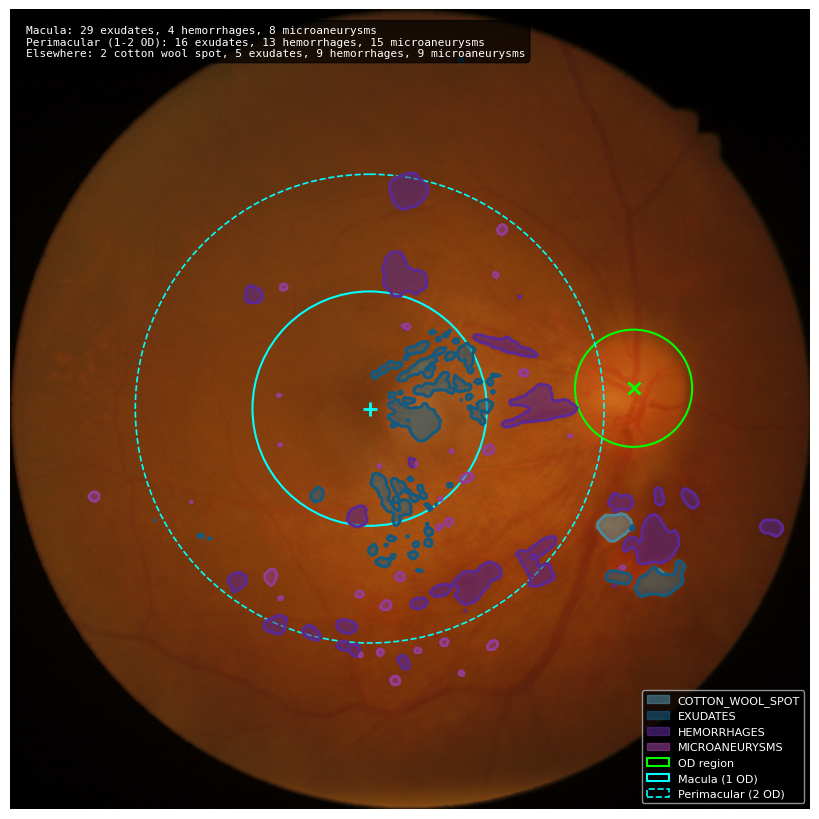

In [26]:
plot_image_lesions(
    DDR_TEST,
    "007-6183-300",
    lesions_df_test,
    ods_df_test,
    show_region_counts=True,
    fig_size=8,
    save_file=Path(
        "/home/clement/Documents/Projets/MultiStyleSeg/paper/images/DDR_007-6183-300.png"
    ),
)

In [27]:
gt = pd.read_csv(
    "/home/clement/Documents/data/DDR-dataset/DR_grading/test.txt",
    header=None,
    sep=" ",
    names=["image_id", "label"],
)
xs = []
ys = []
# We create a mapping from lesion_id to an integer index
for image_id, series in tqdm(geo_df.iterrows(), total=geo_df.shape[0]):
    # Recover the rest of the values as a numpy array
    x = np.array(series, dtype=np.float32)
    xs.append(x)
    y = gt[gt["image_id"] == image_id + ".jpg"]["label"].values[0]
    ys.append(y)


  0%|          | 0/3759 [00:00<?, ?it/s]

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    cohen_kappa_score,
    make_scorer,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
)


xs = np.array(xs)
ys = np.array(ys)
xs = xs[ys != 6]
Y = ys[ys != 6] > 1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

results = {}
cv_auc = cross_val_score(
    lr,
    xs,
    Y,
    cv=cv,
    scoring=make_scorer(roc_auc_score),
)
results["All lesions (LR, 5-fold CV)"] = {
    "AUC-ROC mean": cv_auc.mean(),
    "AUC-ROC std": cv_auc.std(),
}
results

{'All lesions (LR, 5-fold CV)': {'AUC-ROC mean': 0.8637064602599436,
  'AUC-ROC std': 0.016607628541929497}}

In [38]:
ys

array([1, 1, 1, ..., 2, 2, 2])